In [75]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Dataset.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Below we do One-Hot encoding which is used for the purpose of dividing differnet categories under single feature into differnet features with option as 0 or 1. see ChestPaintype here we have 4 options so we make each option as a feature and then give it option of true and false. Sex was already two type so we can just map M as 0 and F as 1 but that does not affect much anyway so your wish...

In [6]:
encode_var = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

df = pd.get_dummies(data=df, prefix=encode_var, columns=encode_var)

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [11]:
X = df[[x for x in df.columns if x != 'HeartDisease']]
Y = df['HeartDisease']

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state = 55)

X_train.shape

(734, 20)

1.Decission Tree

Below is the decision tree code to check which depth gives best accuracy in test data and not overfitting or underfitting

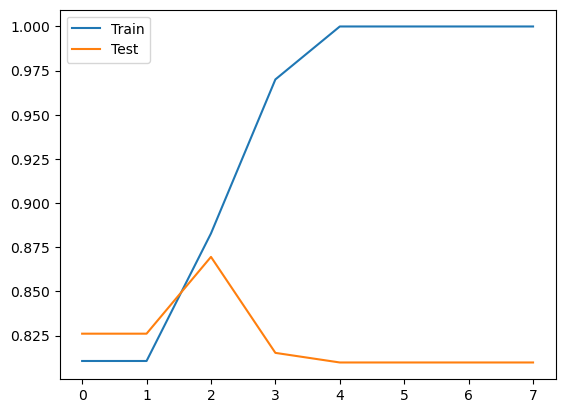

In [25]:
acc_train = []
acc_test  = []
depth = [1, 2, 4, 8, 16, 32, 64, None]

for d in depth:
    model = DecisionTreeClassifier(max_depth = d, random_state = 55)
    model.fit(X_train, Y_train)
    acc_train.append(accuracy_score(model.predict(X_train), Y_train))
    acc_test.append(accuracy_score(model.predict(X_test), Y_test))

plt.plot(acc_train, label='Train')
plt.plot(acc_test, label='Test')
plt.legend()
plt.show()

In [24]:
print(f" Best accuracy at depth = {depth[2]}\n Accuracy of training data = {acc_train[2]*100:.2f} \n Accuracy of test data = {acc_test[2]*100 : .2f} ")

 Best accuracy at depth = 4
 Accuracy of training data = 88.28 
 Accuracy of test data =  86.96 


2. Random Forest

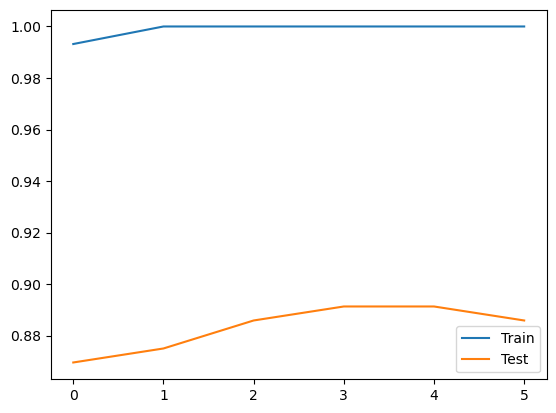

In [32]:
rf_acc_train = []
rf_acc_test = []
num_trees = [16, 32, 64, 100, 128, 500]

for num in num_trees:
    model = RandomForestClassifier(n_estimators=num, random_state=55)
    model.fit(X_train, Y_train)

    rf_acc_train.append(accuracy_score(model.predict(X_train), Y_train))
    rf_acc_test.append(accuracy_score(model.predict(X_test), Y_test))

plt.plot(rf_acc_train, label='Train')
plt.plot(rf_acc_test, label='Test')
plt.legend()
plt.show()

In [33]:
print(f"Accuracy for number of decision trees = 100 is {rf_acc_test[3]*100: .2f}\nAccuracy for number of decision trees = 128 is {rf_acc_test[4]*100: .2f} ")

Accuracy for number of decision trees = 100 is  89.13
Accuracy for number of decision trees = 128 is  89.13 


From above we see we got best results in test data around 100 decision trees but it also started overfiting so we will see if we can correct overfitting little bit by now fixing the n_estimators = 100 and changing the max_depth criteria

[]

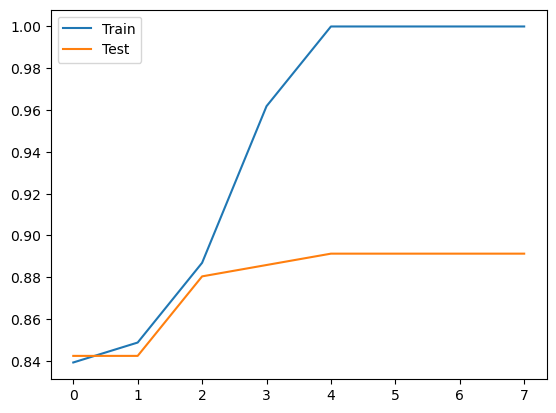

In [68]:
rf_acc_test = []
rf_acc_train = []

for d in depth:
    model = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=55)
    model.fit(X_train, Y_train)

    rf_acc_train.append(accuracy_score(model.predict(X_train), Y_train))
    rf_acc_test.append(accuracy_score(model.predict(X_test), Y_test))

plt.plot(rf_acc_train, label="Train")
plt.plot(rf_acc_test, label="Test")
plt.legend()
plt.plot()

In [69]:
print(f"Accuracy for Test Data is {rf_acc_test[4]*100: .2f}")
print(f"Accuracy for Train data is {rf_acc_train[4]*100: .2f}")
#Overfitting here

Accuracy for Test Data is  89.13
Accuracy for Train data is  100.00


[]

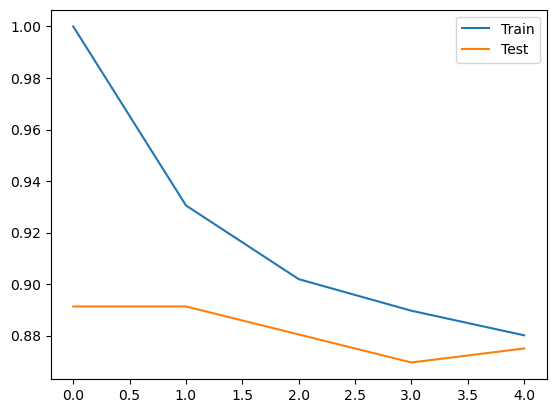

In [71]:
#max_depth = 16

splits = [2, 10, 20, 30, 50]

rf_acc_test = []
rf_acc_train = []

for s in splits:
    model = RandomForestClassifier(n_estimators=100, min_samples_split=s, max_depth=16, random_state=55)
    model.fit(X_train, Y_train)

    rf_acc_train.append(accuracy_score(model.predict(X_train), Y_train))
    rf_acc_test.append(accuracy_score(model.predict(X_test), Y_test))

plt.plot(rf_acc_train, label="Train")
plt.plot(rf_acc_test, label="Test")
plt.legend()
plt.plot()


In [73]:
print(f"Accuracy for Test Data is {rf_acc_test[1]*100: .2f}")
print(f"Accuracy for Train data is {rf_acc_train[1]*100: .2f}")

Accuracy for Test Data is  89.13
Accuracy for Train data is  93.05


3. XGBoost

In [38]:
n  = int(len(X_train)*0.8)
X_fit, X_eval = X_train[:n], X_train[n:]
Y_fit, Y_eval = Y_train[:n], Y_train[n:]

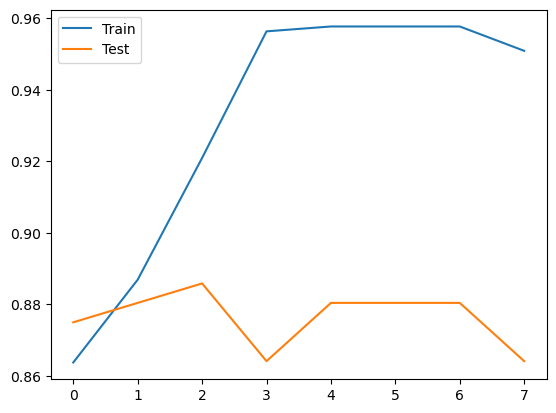

In [57]:
xgb_acc_train = []
xgb_acc_test = []

for d in depth:
    xgb_model = XGBClassifier(n_estimators=500, learning_rate=0.01, max_depth=d, random_state = 55)
    
    xgb_model.fit(X_fit, Y_fit,
                  eval_set = [(X_eval, Y_eval)],
                  verbose=False
    )

    xgb_acc_train.append(accuracy_score(xgb_model.predict(X_train), Y_train))
    xgb_acc_test.append(accuracy_score(xgb_model.predict(X_test), Y_test))

plt.plot(xgb_acc_train, label='Train')
plt.plot(xgb_acc_test, label='Test')
plt.legend()
plt.show()

In [58]:
print(f"Accuracy Score on Training Data by XGBOOST Model: {xgb_acc_train[2]*100: .2f}")
print(f"Accuracy Score on Test Data by XGBOOST Model: {xgb_acc_test[2]*100: .2f}")

Accuracy Score on Training Data by XGBOOST Model:  92.10
Accuracy Score on Test Data by XGBOOST Model:  88.59


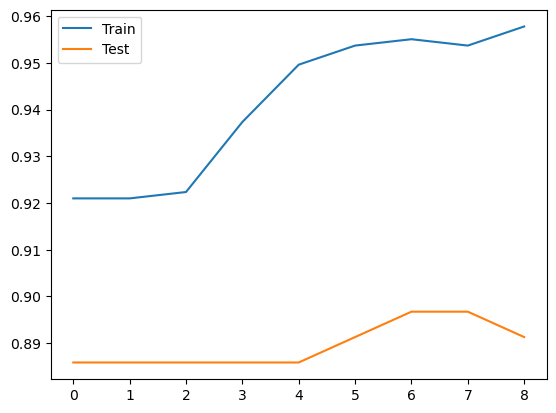

In [61]:
#max_depth = 4 fixed

n_estimators_list = [500, 512, 600, 800, 1000, 1200, 1500, 1750, 2024]

xgb_acc_train = []
xgb_acc_test = []

for n in n_estimators_list:
    xgb_model = XGBClassifier(n_estimators=n, learning_rate=0.01, max_depth=4, random_state = 55)
    
    xgb_model.fit(X_fit, Y_fit,
                  eval_set = [(X_eval, Y_eval)],
                  verbose=False
    )

    xgb_acc_train.append(accuracy_score(xgb_model.predict(X_train), Y_train))
    xgb_acc_test.append(accuracy_score(xgb_model.predict(X_test), Y_test))

plt.plot(xgb_acc_train, label='Train')
plt.plot(xgb_acc_test, label='Test')
plt.legend()
plt.show()

In [64]:
print(f"Accuracy Score on Training Data by XGBOOST Model: {xgb_acc_train[6]*100: .2f}")
print(f"Accuracy Score on Test Data by XGBOOST Model: {xgb_acc_test[6]*100: .2f}")

Accuracy Score on Training Data by XGBOOST Model:  95.50
Accuracy Score on Test Data by XGBOOST Model:  89.67


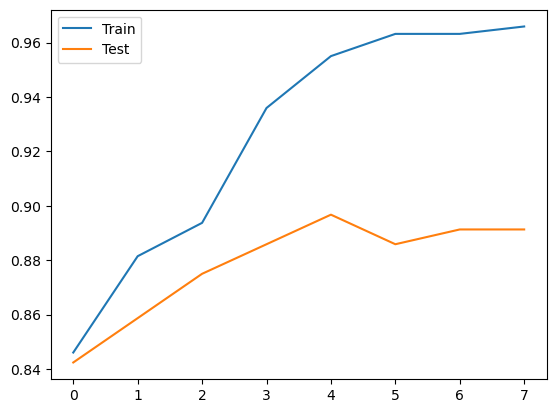

In [66]:
#n_estimators = 1500

learning_rate_list = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

xgb_acc_train = []
xgb_acc_test = []

for alpha in learning_rate_list:
    xgb_model = XGBClassifier(n_estimators=1500, learning_rate=alpha, max_depth=4, random_state = 55)
    
    xgb_model.fit(X_fit, Y_fit,
                  eval_set = [(X_eval, Y_eval)],
                  verbose=False
    )

    xgb_acc_train.append(accuracy_score(xgb_model.predict(X_train), Y_train))
    xgb_acc_test.append(accuracy_score(xgb_model.predict(X_test), Y_test))

plt.plot(xgb_acc_train, label='Train')
plt.plot(xgb_acc_test, label='Test')
plt.legend()
plt.show()

In [67]:
print(f"Accuracy Score on Training Data by XGBOOST Model: {xgb_acc_train[4]*100: .2f}")
print(f"Accuracy Score on Test Data by XGBOOST Model: {xgb_acc_test[4]*100: .2f}")

Accuracy Score on Training Data by XGBOOST Model:  95.50
Accuracy Score on Test Data by XGBOOST Model:  89.67


4. Final Review

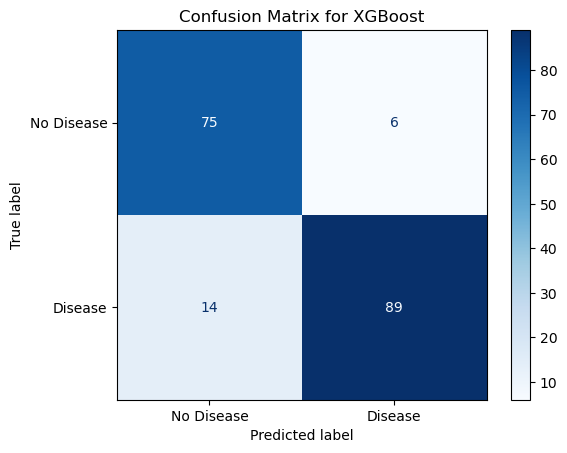

In [76]:
Y_pred = xgb_model.predict(X_test)
cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix for XGBoost")
plt.show()

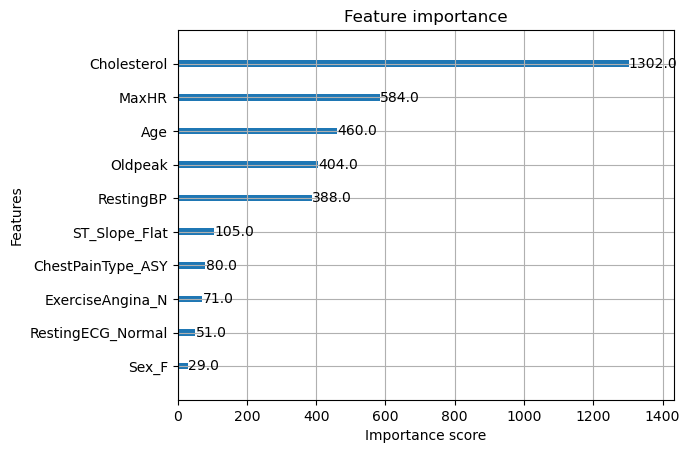

In [77]:
from xgboost import plot_importance
plot_importance(xgb_model, max_num_features=10)
plt.show()